# Probability Plot

**Module 3: Probability Distributions** | Lean Six Sigma Data Analytics

---

## The Question

You know what a normal distribution looks like. But **how do you know if your data follows this distribution?**

## Why Does It Matter?

You need to know which distribution fits your data for many statistical tools:
- Empirical CDF
- ANOVA
- Regression

The **probability plot** is the tool to answer this question.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)
print('Data loaded successfully!')

Data loaded successfully!


---

## Example: Call Center Total Handling Time

A project has started to improve the **Total Handling Time (THT)** at a call center—the total time an employee is busy answering a call.

**CTQ:** Total Handling Time (seconds)

In [2]:
# Load Total Handling Time (THT) data
tht_df = pd.read_excel(xlsx, sheet_name='THT', skiprows=8)
tht_df.columns = ['THT', 'Training', 'Extra']
tht_df = tht_df[['THT']].dropna()
tht_df['THT'] = pd.to_numeric(tht_df['THT'], errors='coerce')
tht_df = tht_df.dropna()

tht_data = tht_df['THT'].values

print('Total Handling Time (THT) Data')
print(f'Sample size: {len(tht_data)}')
print(f'Mean: {tht_data.mean():.1f} seconds')
print(f'Median: {np.median(tht_data):.1f} seconds')
print(f'Min: {tht_data.min():.1f}, Max: {tht_data.max():.1f}')

Total Handling Time (THT) Data
Sample size: 56
Mean: 280.3 seconds
Median: 211.5 seconds
Min: 61.0, Max: 910.0


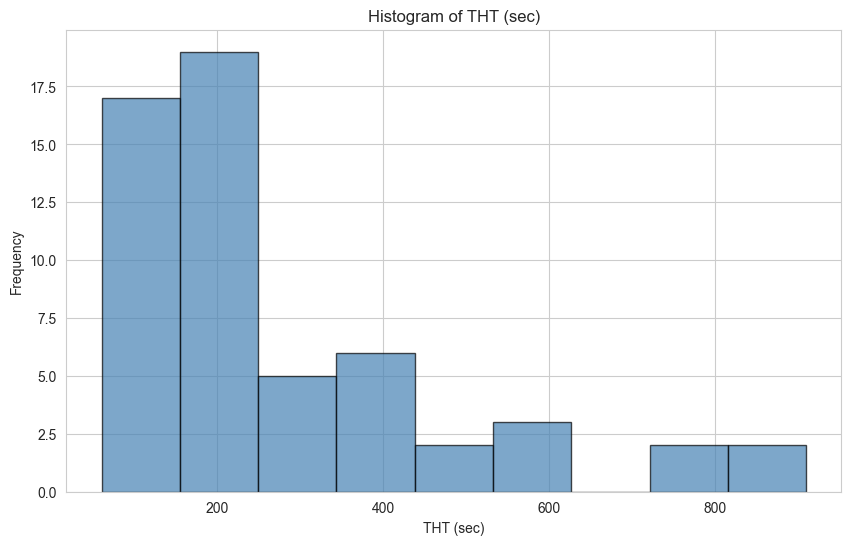

From the shape, we can see the data is NOT normally distributed.
But is it Weibull or Lognormal? We need a probability plot to find out.


In [3]:
# Histogram of THT data
plt.figure(figsize=(10, 6))
plt.hist(tht_data, bins=9, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('THT (sec)')
plt.ylabel('Frequency')
plt.title('Histogram of THT (sec)')
plt.show()

print('From the shape, we can see the data is NOT normally distributed.')
print('But is it Weibull or Lognormal? We need a probability plot to find out.')

---

## What is a Probability Plot?

A probability plot compares your data to a theoretical distribution.

**How to read it:**
- Data points should lie on a **straight line**
- Points should fall **between the confidence bands**
- **Good fit:** Data on the line
- **Poor fit:** Data curves away from the line

**Minitab:** Graph > Probability Plot > Single

---

## Probability Plot: Normal Distribution

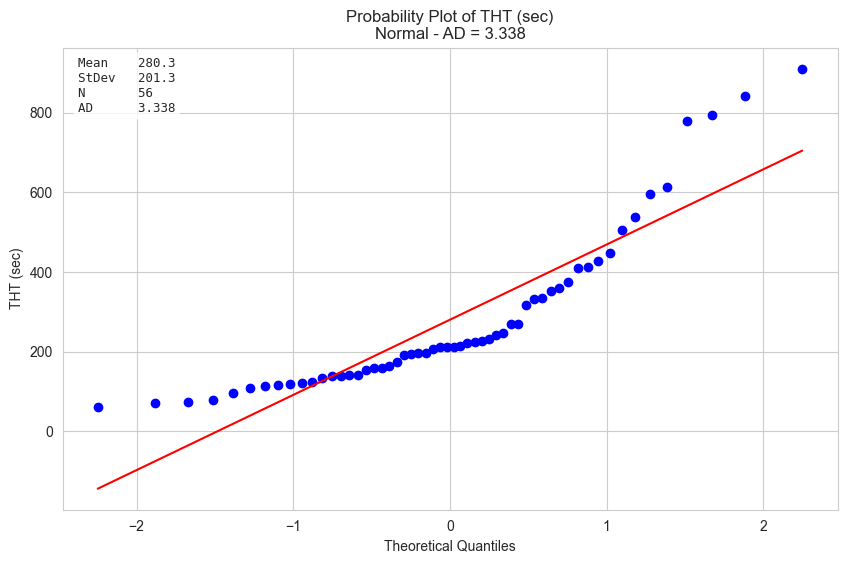

Interpretation:
  - Data points CURVE AWAY from the straight line
  - The Normal distribution is a POOR FIT for THT
  - Anderson-Darling statistic: 3.338


In [4]:
# Probability Plot for Normal Distribution
# Equivalent to Minitab: Graph > Probability Plot > Single > Normal

fig, ax = plt.subplots(figsize=(10, 6))
res = stats.probplot(tht_data, dist='norm', plot=ax)

# Calculate Anderson-Darling statistic
ad_stat, _, _ = stats.anderson(tht_data, dist='norm')

ax.set_title(f'Probability Plot of THT (sec)\nNormal - AD = {ad_stat:.3f}')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('THT (sec)')

# Add stats text box
stats_text = f'Mean    {tht_data.mean():.1f}\nStDev   {tht_data.std():.1f}\nN       {len(tht_data)}\nAD      {ad_stat:.3f}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        family='monospace')

plt.show()

print('Interpretation:')
print('  - Data points CURVE AWAY from the straight line')
print('  - The Normal distribution is a POOR FIT for THT')
print(f'  - Anderson-Darling statistic: {ad_stat:.3f}')

---

## Probability Plot: Weibull Distribution

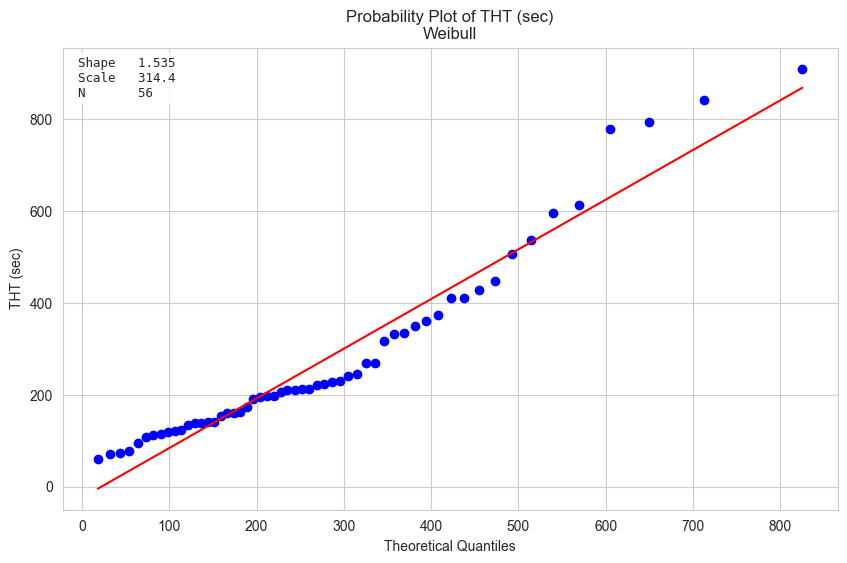

Interpretation:
  - Data points show some deviation from the line
  - The Weibull distribution is NOT the best fit


In [5]:
# Probability Plot for Weibull Distribution
# Equivalent to Minitab: Graph > Probability Plot > Single > Weibull

# Fit Weibull parameters
shape, loc, scale = stats.weibull_min.fit(tht_data, floc=0)

fig, ax = plt.subplots(figsize=(10, 6))
res = stats.probplot(tht_data, dist=stats.weibull_min, sparams=(shape, loc, scale), plot=ax)

ax.set_title(f'Probability Plot of THT (sec)\nWeibull')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('THT (sec)')

# Add stats text box
stats_text = f'Shape   {shape:.3f}\nScale   {scale:.1f}\nN       {len(tht_data)}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        family='monospace')

plt.show()

print('Interpretation:')
print('  - Data points show some deviation from the line')
print('  - The Weibull distribution is NOT the best fit')

---

## Probability Plot: Lognormal Distribution

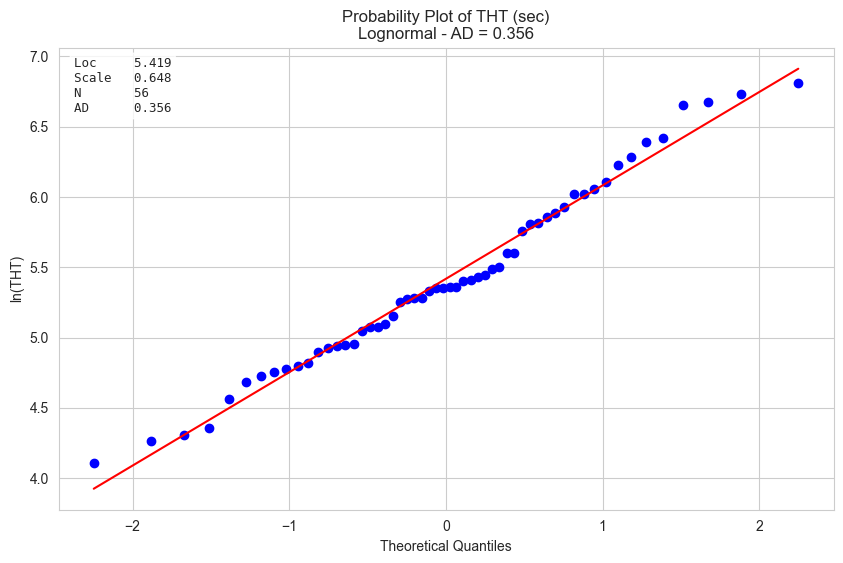

Interpretation:
  - Data points LIE CLOSE to the straight line
  - The Lognormal distribution is a GOOD FIT!
  - Anderson-Darling statistic: 0.356 (lower is better)


In [6]:
# Probability Plot for Lognormal Distribution
# Equivalent to Minitab: Graph > Probability Plot > Single > Lognormal
# For lognormal: if X is lognormal, then log(X) is normal

fig, ax = plt.subplots(figsize=(10, 6))

# Take log of data and check normality
log_tht = np.log(tht_data)
res = stats.probplot(log_tht, dist='norm', plot=ax)

# Anderson-Darling on log-transformed data
ad_stat_log, _, _ = stats.anderson(log_tht, dist='norm')

ax.set_title(f'Probability Plot of THT (sec)\nLognormal - AD = {ad_stat_log:.3f}')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('ln(THT)')

# Add stats text box
stats_text = f'Loc     {log_tht.mean():.3f}\nScale   {log_tht.std():.3f}\nN       {len(tht_data)}\nAD      {ad_stat_log:.3f}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        family='monospace')

plt.show()

print('Interpretation:')
print('  - Data points LIE CLOSE to the straight line')
print('  - The Lognormal distribution is a GOOD FIT!')
print(f'  - Anderson-Darling statistic: {ad_stat_log:.3f} (lower is better)')

---

## Comparing All Three Distributions

In [7]:
# Summary comparison of AD statistics
ad_norm, _, _ = stats.anderson(tht_data, dist='norm')
ad_lognorm, _, _ = stats.anderson(np.log(tht_data), dist='norm')

print('COMPARISON OF DISTRIBUTION FITS')
print('=' * 50)
print(f'Normal:    AD = {ad_norm:.3f}  - Poor fit (data curves away)')
print(f'Lognormal: AD = {ad_lognorm:.3f}  - Good fit (data on line)')
print()
print('CONCLUSION: Lognormal distribution fits best (lowest AD value)')
print()
print('Rule: Select the distribution with the LOWEST AD value')

COMPARISON OF DISTRIBUTION FITS
Normal:    AD = 3.338  - Poor fit (data curves away)
Lognormal: AD = 0.356  - Good fit (data on line)

CONCLUSION: Lognormal distribution fits best (lowest AD value)

Rule: Select the distribution with the LOWEST AD value


---

## Anderson-Darling (AD) Statistic

The **Anderson-Darling statistic** measures the distance between your data and the theoretical distribution.

| AD Value | Interpretation |
|----------|----------------|
| **Lower** | Better fit |
| **Higher** | Worse fit |

**Rule:** Select the distribution with the **lowest AD value**.

---

## Spotting Data Anomalies

Probability plots can also help detect data problems:

| Pattern | Meaning |
|---------|--------|
| Points far from line at ends | **Outliers** |
| S-shaped curve | **Bimodality** (two distributions mixed) |
| Small stacks/steps | **Rounded data** (focus on midpoints) |

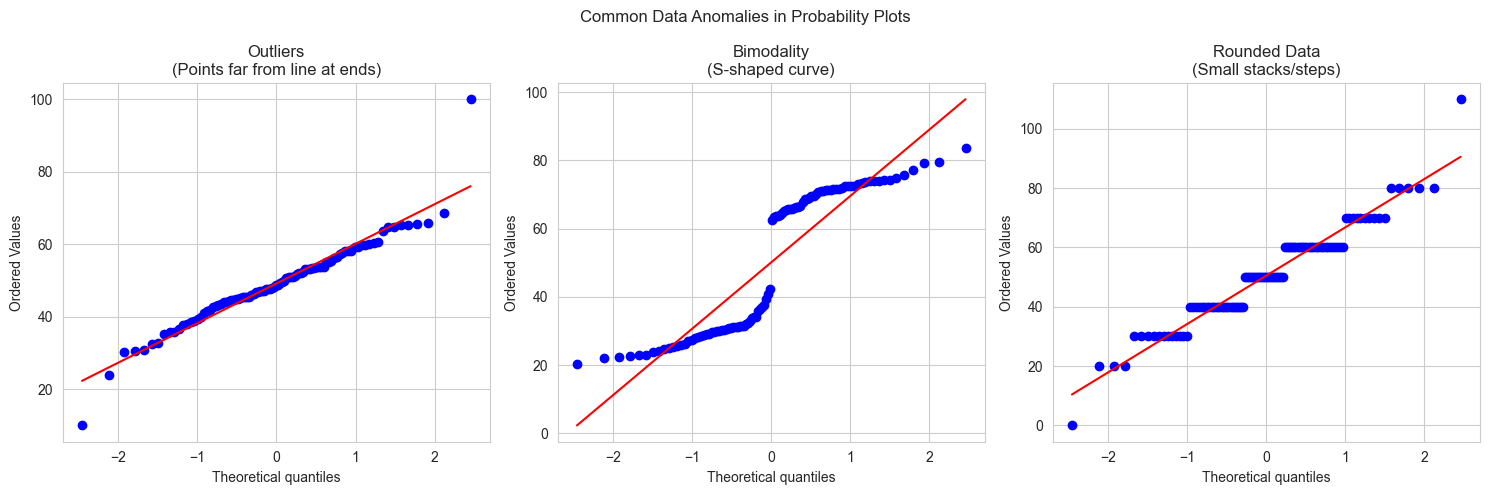

In [8]:
# Demonstrate common anomalies
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Outliers
data_outliers = np.concatenate([np.random.normal(50, 10, 95), [10, 100]])
stats.probplot(data_outliers, dist='norm', plot=axes[0])
axes[0].set_title('Outliers\n(Points far from line at ends)')

# 2. Bimodality (S-shape)
data_bimodal = np.concatenate([np.random.normal(30, 5, 50), np.random.normal(70, 5, 50)])
stats.probplot(data_bimodal, dist='norm', plot=axes[1])
axes[1].set_title('Bimodality\n(S-shaped curve)')

# 3. Rounded data (steps)
data_rounded = np.round(np.random.normal(50, 15, 100) / 10) * 10
stats.probplot(data_rounded, dist='norm', plot=axes[2])
axes[2].set_title('Rounded Data\n(Small stacks/steps)')

plt.suptitle('Common Data Anomalies in Probability Plots', fontsize=12)
plt.tight_layout()
plt.show()

---

## Summary: Reading Probability Plots

| What to Look For | Interpretation |
|------------------|----------------|
| Data on straight line | **Good fit** |
| Data between confidence lines | **Good fit** |
| Data curves away from line | **Poor fit** |
| Lower AD statistic | **Better fit** |

---

## Key Takeaways

- **Probability plot** determines which distribution fits your data best
- **Good fit:** Data points lie on a straight line, between confidence bands
- **Poor fit:** Data points deviate from the line
- **Anderson-Darling (AD):** Lower value = better fit
- **Anomalies:** Outliers, bimodality (S-shape), rounded data (steps)
- **Three distributions to try:** Normal, Weibull, Lognormal